# Phase 2b 拡張: トポロジカル監査（一気通貫版）

## 使い方
1. 右パネル → **Add Data** で Phase 1 dataset と Phase 2a checkpoint を追加
2. 右パネル → **Settings** → Accelerator → **GPU T4** を選択
3. 上メニュー → **Save & Run All (Commit)** で全セル自動実行
4. 完了後、Output に `.npz` と `.png` が全て残る

**所要時間**: 約 3.5 時間（DDPM 生成 3h + 監査 0.5h）

In [7]:
# ═══ 0. データ & チェックポイント探索 ═══
import os, glob, time
import numpy as np

# Phase 1 .npz
DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    npz = [f for f in files if f.endswith('.npz')]
    if npz:
        DATA_DIR = root
        break
if DATA_DIR is None:
    raise FileNotFoundError('.npz が見つかりません。Add Data で Phase 1 dataset を追加してください。')
print(f'Phase 1 data: {DATA_DIR}')

# Checkpoint .pt
CKPT_PATH = None
for root, dirs, files in os.walk('/kaggle/input/models'):
    for f in files:
        if f.endswith('.pt') and 'final' in f:
            CKPT_PATH = os.path.join(root, f)
            break
    if CKPT_PATH:
        break
if CKPT_PATH is None:
    raise FileNotFoundError('.pt が見つかりません。Add Data → Models で checkpoint を追加してください。')
print(f'Checkpoint: {CKPT_PATH}')

Phase 1 data: /kaggle/input/datasets/mokafe/phase1-dataset
Checkpoint: /kaggle/input/models/mokafe/phase2a-ddpm-checkpoint/pytorch/default/1/ckpt_final.pt


In [8]:
# ═══ 1. MC データ読み込み ═══
mc_data = {}
for f in sorted(glob.glob(os.path.join(DATA_DIR, '*.npz'))):
    beta = float(os.path.basename(f).split('beta_')[1].split('.npz')[0])
    d = np.load(f)
    mc_data[beta] = {'re': d['poly_re'].astype(np.float32), 'im': d['poly_im'].astype(np.float32)}
    print(f'β={beta:.2f}: {mc_data[beta]["re"].shape[0]} configs')
print(f'mc_data: {len(mc_data)} β values ✓')

β=0.50: 500 configs
β=1.00: 500 configs
β=1.50: 500 configs
β=1.70: 500 configs
β=1.90: 500 configs
β=10.00: 500 configs
β=2.00: 500 configs
β=2.50: 500 configs
β=4.00: 500 configs
β=6.00: 500 configs
mc_data: 10 β values ✓


In [13]:
# ═══ 2. モデル定義（Phase 2a と同一）═══
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def circ_conv(in_ch, out_ch, kernel_size=3, stride=1, bias=True):
    return nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride,
                     padding=kernel_size // 2, padding_mode='circular', bias=bias)

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ConditionEmbedding(nn.Module):
    def __init__(self, d_model=256):
        super().__init__()
        self.time_sin = SinusoidalEmbedding(d_model)
        self.time_mlp = nn.Sequential(nn.Linear(d_model, d_model), nn.SiLU(), nn.Linear(d_model, d_model))
        self.beta_mlp = nn.Sequential(nn.Linear(1, d_model), nn.SiLU(), nn.Linear(d_model, d_model))
        self.combine = nn.Sequential(nn.SiLU(), nn.Linear(d_model, d_model))
    def forward(self, t, beta_normed):
        return self.combine(self.time_mlp(self.time_sin(t)) + self.beta_mlp(beta_normed[:, None]))

class AdaGN(nn.Module):
    def __init__(self, n_ch, d_cond, n_groups=8):
        super().__init__()
        self.gn = nn.GroupNorm(n_groups, n_ch, affine=False)
        self.proj = nn.Linear(d_cond, 2 * n_ch)
    def forward(self, x, cond):
        h = self.gn(x)
        s, sh = self.proj(cond)[:, :, None, None].chunk(2, dim=1)
        return h * (1 + s) + sh

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, d_cond=256, n_groups=8):
        super().__init__()
        self.conv1 = circ_conv(in_ch, out_ch)
        self.adagn = AdaGN(out_ch, d_cond, min(n_groups, out_ch))
        self.conv2 = circ_conv(out_ch, out_ch)
        self.act = nn.SiLU()
        self.skip_proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = self.act(self.conv1(x))
        h = self.act(self.adagn(h, cond))
        return self.conv2(h) + self.skip_proj(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, 3 * ch, 1)
        self.out = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x)).reshape(B, 3, self.n_heads, C // self.n_heads, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = torch.einsum('bhdn,bhdm->bhnm', q, k) / math.sqrt(C // self.n_heads)
        out = torch.einsum('bhnm,bhdm->bhdn', attn.softmax(dim=-1), v).reshape(B, C, H, W)
        return x + self.out(out)

class UNet(nn.Module):
    def __init__(self, in_ch=2, ch_mults=(64, 128, 256), d_cond=256):
        super().__init__()
        self.cond_emb = ConditionEmbedding(d_cond)
        c0, c1, c2 = ch_mults
        self.in_conv = circ_conv(in_ch, c0)
        self.down1a = ResBlock(c0, c0, d_cond); self.down1b = ResBlock(c0, c0, d_cond)
        self.pool1 = nn.Conv2d(c0, c0, 3, stride=2, padding=1, padding_mode='circular')
        self.down2a = ResBlock(c0, c1, d_cond); self.down2b = ResBlock(c1, c1, d_cond)
        self.pool2 = nn.Conv2d(c1, c1, 3, stride=2, padding=1, padding_mode='circular')
        self.down3a = ResBlock(c1, c2, d_cond); self.down3b = ResBlock(c2, c2, d_cond)
        self.pool3 = nn.Conv2d(c2, c2, 3, stride=2, padding=1, padding_mode='circular')
        self.bot1 = ResBlock(c2, c2, d_cond); self.bot_attn = SelfAttention(c2); self.bot2 = ResBlock(c2, c2, d_cond)
        self.up3 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec3a = ResBlock(c2*2, c2, d_cond); self.dec3b = ResBlock(c2, c2, d_cond)
        self.up2 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.dec2a = ResBlock(c1*2, c1, d_cond); self.dec2b = ResBlock(c1, c1, d_cond)
        self.up1 = nn.ConvTranspose2d(c1, c0, 2, stride=2)
        self.dec1a = ResBlock(c0*2, c0, d_cond); self.dec1b = ResBlock(c0, c0, d_cond)
        self.out_norm = nn.GroupNorm(8, c0)
        self.out_conv = circ_conv(c0, in_ch)
        nn.init.zeros_(self.out_conv.weight); nn.init.zeros_(self.out_conv.bias)
    def forward(self, x, t, beta_normed):
        cond = self.cond_emb(t, beta_normed)
        h = self.in_conv(x)
        s1 = self.down1b(self.down1a(h, cond), cond); h = self.pool1(s1)
        s2 = self.down2b(self.down2a(h, cond), cond); h = self.pool2(s2)
        s3 = self.down3b(self.down3a(h, cond), cond); h = self.pool3(s3)
        h = self.bot2(self.bot_attn(self.bot1(h, cond)), cond)
        h = self.dec3b(self.dec3a(torch.cat([self.up3(h), s3], 1), cond), cond)
        h = self.dec2b(self.dec2a(torch.cat([self.up2(h), s2], 1), cond), cond)
        h = self.dec1b(self.dec1a(torch.cat([self.up1(h), s1], 1), cond), cond)
        return self.out_conv(F.silu(self.out_norm(h)))

class CosineSchedule:
    def __init__(self, T=1000, s=0.008):
        self.T = T
        steps = torch.arange(T + 1, dtype=torch.float64)
        f = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        ab = f / f[0]
        betas = (1 - ab[1:] / ab[:-1]).clamp(max=0.999)
        self.betas = betas.float()
        self.alphas = (1 - self.betas).float()
        self.alpha_bar = torch.cumprod(self.alphas, 0).float()
        self.sqrt_ab = torch.sqrt(self.alpha_bar)
        self.sqrt_omab = torch.sqrt(1 - self.alpha_bar)
    def to(self, dev):
        for a in ['betas','alphas','alpha_bar','sqrt_ab','sqrt_omab']:
            setattr(self, a, getattr(self, a).to(dev))
        return self
    def p_sample(self, model, x_t, t, bn):
        B = x_t.shape[0]
        tt = torch.full((B,), t, device=x_t.device, dtype=torch.long)
        with torch.no_grad():
            eps = model(x_t, tt, bn)
        mean = (1/torch.sqrt(self.alphas[t])) * (x_t - self.betas[t]/self.sqrt_omab[t] * eps)
        return mean + torch.sqrt(self.betas[t]) * torch.randn_like(x_t) if t > 0 else mean
    @torch.no_grad()
    def sample(self, model, shape, bn, show_progress=True):
        x = torch.randn(shape, device=bn.device)
        steps = range(self.T - 1, -1, -1)
        if show_progress:
            try:
                from tqdm import tqdm; steps = tqdm(steps, desc='Sampling')
            except: pass
        for t in steps:
            x = self.p_sample(model, x, t, bn)
        return x

print('モデル定義完了 ✓')

Device: cuda
モデル定義完了 ✓


In [14]:
# ═══ 3. チェックポイントロード & DDPM 生成 ═══
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
ema_model = UNet(in_ch=2).to(device)
ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()
print(f'EMA model loaded: {sum(p.numel() for p in ema_model.parameters())/1e6:.1f}M params')

ds_info = ckpt.get('dataset_info', {})
BETA_MIN = ds_info.get('beta_min', 0.5)
BETA_MAX = ds_info.get('beta_max', 10.0)
def beta_to_normed(b): return (b - BETA_MIN) / (BETA_MAX - BETA_MIN + 1e-8)

schedule = CosineSchedule(T=1000).to(device)

N_GEN = 1000
GEN_BATCH = 100
all_betas = sorted(set(list(mc_data.keys()) + [1.75, 1.85, 3.0, 8.0]))

gen_data = {}
t0 = time.time()
for beta in all_betas:
    bn = beta_to_normed(beta)
    samples = []
    for i in range(math.ceil(N_GEN / GEN_BATCH)):
        bs = min(GEN_BATCH, N_GEN - i * GEN_BATCH)
        bt = torch.full((bs,), bn, device=device)
        s = schedule.sample(ema_model, (bs, 2, 32, 32), bt, show_progress=False)
        samples.append(s.cpu().numpy())
    samples = np.concatenate(samples)
    gen_data[beta] = {'re': samples[:, 0], 'im': samples[:, 1]}
    print(f'β={beta:.2f}: {samples.shape[0]}枚 ({time.time()-t0:.0f}s)')
print(f'\n全生成完了: {time.time()-t0:.0f}s')

EMA model loaded: 12.1M params
β=0.50: 1000枚 (910s)
β=1.00: 1000枚 (1821s)
β=1.50: 1000枚 (2738s)
β=1.70: 1000枚 (3650s)
β=1.75: 1000枚 (4568s)
β=1.85: 1000枚 (5486s)
β=1.90: 1000枚 (6403s)
β=2.00: 1000枚 (7320s)
β=2.50: 1000枚 (8241s)
β=3.00: 1000枚 (9159s)
β=4.00: 1000枚 (10077s)
β=6.00: 1000枚 (10994s)
β=8.00: 1000枚 (11912s)
β=10.00: 1000枚 (12828s)

全生成完了: 12828s


In [17]:
# ═══ 4. データ保存（確実に Output に残す）═══
save_dict = {}
for beta in sorted(gen_data.keys()):
    save_dict[f'gen_re_{beta}'] = gen_data[beta]['re']
    save_dict[f'gen_im_{beta}'] = gen_data[beta]['im']
for beta in sorted(mc_data.keys()):
    save_dict[f'mc_re_{beta}'] = mc_data[beta]['re']
    save_dict[f'mc_im_{beta}'] = mc_data[beta]['im']
save_dict['gen_betas'] = np.array(sorted(gen_data.keys()))
save_dict['mc_betas'] = np.array(sorted(mc_data.keys()))

np.savez_compressed('/kaggle/working/phase2b_data.npz', **save_dict)
sz = os.path.getsize('/kaggle/working/phase2b_data.npz') / 1024**2
print(f'保存完了: phase2b_data.npz ({sz:.1f} MB)')

保存完了: phase2b_data.npz (134.9 MB)


In [18]:
# ═══ 5. 監査関数定義 ═══
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.optimize import linear_sum_assignment

OUTDIR = Path('/kaggle/working')

def wrap_angle(d): return (d + np.pi) % (2*np.pi) - np.pi

def pbc_distance_matrix(pa, pb, ns):
    if len(pa)==0 or len(pb)==0: return np.empty((len(pa),len(pb)))
    dx = np.abs(pa[:,None,0]-pb[None,:,0]); dy = np.abs(pa[:,None,1]-pb[None,:,1])
    return np.sqrt(np.minimum(dx,ns-dx)**2 + np.minimum(dy,ns-dy)**2)

def analyze_config(re, im, amp_eps=0.05, rounding_tol=0.10, project=True):
    ns = re.shape[0]
    z = re.astype(np.float64) + 1j*im.astype(np.float64)
    rho = np.abs(z); low = rho < amp_eps
    if project:
        zp = np.zeros_like(z); g = ~low; zp[g] = z[g]/rho[g]
        theta = np.angle(zp)
    else:
        theta = np.angle(z)
    raw = np.zeros((ns,ns))
    vmap = np.zeros((ns,ns), dtype=np.int8)
    for x in range(ns):
        xp = (x+1)%ns
        for y in range(ns):
            yp = (y+1)%ns
            masked = low[x,y] or low[xp,y] or low[xp,yp] or low[x,yp]
            w = (wrap_angle(theta[xp,y]-theta[x,y]) + wrap_angle(theta[xp,yp]-theta[xp,y])
                + wrap_angle(theta[x,yp]-theta[xp,yp]) + wrap_angle(theta[x,y]-theta[x,yp])) / (2*np.pi)
            raw[x,y] = w
            r = int(np.rint(w))
            if not masked and abs(w-r) <= rounding_tol and r in (-1,0,1):
                vmap[x,y] = r
    np_ = int(np.sum(vmap==1)); nm = int(np.sum(vmap==-1))
    return {'vortex_map': vmap, 'N_plus': np_, 'N_minus': nm,
            'N_v': np_+nm, 'Q': np_-nm, 'raw_windings': raw,
            'max_deviation': float(np.max(np.abs(raw-np.rint(raw)))),
            'norm_violation': float(np.mean(np.abs(re**2+im**2-1.0))),
            'low_amp_frac': float(np.mean(low))}

def analyze_batch(re_stack, im_stack, n_use=500, **kw):
    n = min(n_use, len(re_stack))
    aa = [analyze_config(re_stack[i], im_stack[i], **kw) for i in range(n)]
    Nv = np.array([a['N_v'] for a in aa])
    Q = np.array([a['Q'] for a in aa])
    return {'analyses': aa, 'Nv': Nv, 'Q': Q,
            'Nv_mean': Nv.mean(), 'Nv_std': Nv.std(),
            'Q_nonzero_frac': float(np.mean(Q != 0)),
            'max_round_dev': float(np.max([a['max_deviation'] for a in aa]))}

def nn_vav_dist(vmap, ns=32):
    pp = np.argwhere(vmap==1); pm = np.argwhere(vmap==-1)
    if len(pp)==0 or len(pm)==0: return np.array([])
    return np.min(pbc_distance_matrix(pp, pm, ns), axis=1)

def matched_vav_dist(vmap, ns=32):
    pp = np.argwhere(vmap==1); pm = np.argwhere(vmap==-1)
    n = min(len(pp), len(pm))
    if n==0: return np.array([])
    dm = pbc_distance_matrix(pp, pm, ns)
    ri, ci = linear_sum_assignment(dm)
    return np.sort(dm[ri, ci])[:n]

print('監査関数定義完了 ✓')

監査関数定義完了 ✓


In [19]:
# ═══ 6. 監査実行 ═══
N_TOPO = 500
topo = {}
t0 = time.time()

for beta in sorted(all_betas):
    g = gen_data[beta]
    ge = analyze_batch(g['re'], g['im'], n_use=N_TOPO, project=True)
    ge_raw = analyze_batch(g['re'], g['im'], n_use=N_TOPO, project=False)
    me = None
    if beta in mc_data:
        m = mc_data[beta]
        me = analyze_batch(m['re'], m['im'], n_use=min(N_TOPO, len(m['re'])), project=False)
    topo[beta] = {'gen': ge, 'gen_raw': ge_raw, 'mc': me}
    mc_s = f", MC ⟨Nv⟩={me['Nv_mean']:.1f}" if me else ''
    print(f"β={beta:5.2f}: DDPM ⟨Nv⟩={ge['Nv_mean']:.1f}, Q≠0 {ge['Q_nonzero_frac']*100:.1f}%, "
          f"Δproj={ge['Nv_mean']-ge_raw['Nv_mean']:+.1f}{mc_s} ({time.time()-t0:.0f}s)")

print(f'\n監査計算完了: {time.time()-t0:.0f}s')

β= 0.50: DDPM ⟨Nv⟩=338.4, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=339.8 (8s)
β= 1.00: DDPM ⟨Nv⟩=315.3, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=314.5 (15s)
β= 1.50: DDPM ⟨Nv⟩=183.5, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=179.0 (23s)
β= 1.70: DDPM ⟨Nv⟩=105.8, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=102.9 (31s)
β= 1.75: DDPM ⟨Nv⟩=93.4, Q≠0 0.0%, Δproj=+0.0 (36s)
β= 1.85: DDPM ⟨Nv⟩=59.1, Q≠0 0.0%, Δproj=+0.0 (41s)
β= 1.90: DDPM ⟨Nv⟩=47.6, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=47.8 (49s)
β= 2.00: DDPM ⟨Nv⟩=30.9, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=31.5 (56s)
β= 2.50: DDPM ⟨Nv⟩=6.1, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=6.3 (64s)
β= 3.00: DDPM ⟨Nv⟩=1.7, Q≠0 0.0%, Δproj=+0.0 (69s)
β= 4.00: DDPM ⟨Nv⟩=0.2, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=0.1 (77s)
β= 6.00: DDPM ⟨Nv⟩=0.0, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=0.0 (84s)
β= 8.00: DDPM ⟨Nv⟩=0.0, Q≠0 0.0%, Δproj=+0.0 (89s)
β=10.00: DDPM ⟨Nv⟩=0.0, Q≠0 0.0%, Δproj=+0.0, MC ⟨Nv⟩=0.0 (97s)

監査計算完了: 97s


=== 自己監査 A: Q=0 検証 ===
    β  Q≠0(MC)  Q≠0(DDPM)  |Re²+Im²-1|
─────────────────────────────────────────────
 0.50     0.0%       0.0%       0.0032
 1.00     0.0%       0.0%       0.0031
 1.50     0.0%       0.0%       0.0032
 1.70     0.0%       0.0%       0.0031
 1.75        —       0.0%       0.0031
 1.85        —       0.0%       0.0031
 1.90     0.0%       0.0%       0.0031
 2.00     0.0%       0.0%       0.0031
 2.50     0.0%       0.0%       0.0032
 3.00        —       0.0%       0.0032
 4.00     0.0%       0.0%       0.0032
 6.00     0.0%       0.0%       0.0032
 8.00        —       0.0%       0.0033
10.00     0.0%       0.0%       0.0032

=== 自己監査 B: N_v 整合性 ===
  β= 0.50: ⟨Nv⟩=  338.4, ρ=0.3305
  β= 1.00: ⟨Nv⟩=  315.3, ρ=0.3079
  β= 1.50: ⟨Nv⟩=  183.5, ρ=0.1792
  β= 1.70: ⟨Nv⟩=  105.8, ρ=0.1033
  β= 1.75: ⟨Nv⟩=   93.4, ρ=0.0912
  β= 1.85: ⟨Nv⟩=   59.1, ρ=0.0577
  β= 1.90: ⟨Nv⟩=   47.6, ρ=0.0465
  β= 2.00: ⟨Nv⟩=   30.9, ρ=0.0302
  β= 2.50: ⟨Nv⟩=    6.1, ρ=0.0059
  β= 3.00: ⟨Nv⟩

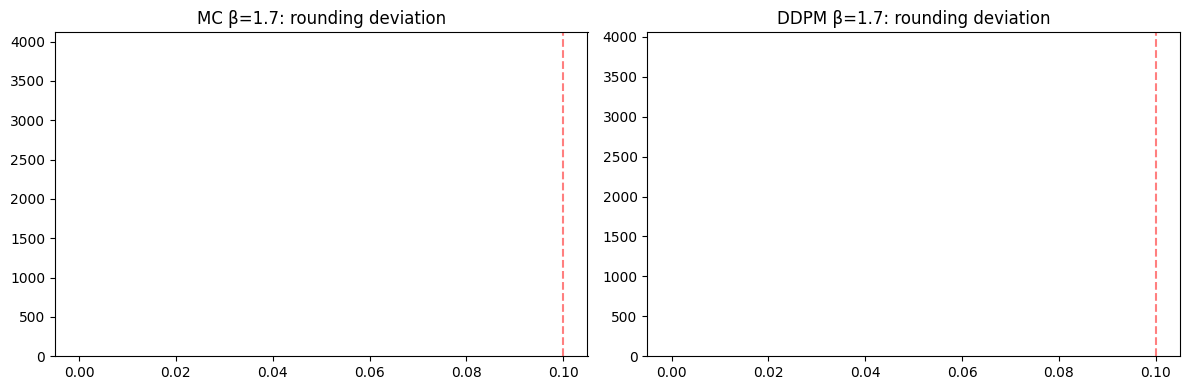

In [20]:
# ═══ 7. 自己監査 A: Q=0, B: N_v整合性, C: 丸め誤差 ═══

print('=== 自己監査 A: Q=0 検証 ===')
print(f"{'β':>5} {'Q≠0(MC)':>8} {'Q≠0(DDPM)':>10} {'|Re²+Im²-1|':>12}")
print('─'*45)
for beta in sorted(all_betas):
    ge = topo[beta]['gen']
    mc_s = f"{topo[beta]['mc']['Q_nonzero_frac']*100:.1f}%" if topo[beta]['mc'] else '—'
    nv_avg = np.mean([a['norm_violation'] for a in ge['analyses']])
    print(f"{beta:5.2f} {mc_s:>8} {ge['Q_nonzero_frac']*100:9.1f}% {nv_avg:12.4f}")

print('\n=== 自己監査 B: N_v 整合性 ===')
ns = 32
for beta in sorted(all_betas):
    ge = topo[beta]['gen']
    # Phase 2b density から予測
    rho_pred = ge['Nv_mean'] / ns**2  # 自己整合チェック
    print(f"  β={beta:5.2f}: ⟨Nv⟩={ge['Nv_mean']:7.1f}, ρ={rho_pred:.4f}")

print('\n=== 自己監査 C: 丸め誤差 ===')
max_dev = max(topo[b]['gen']['max_round_dev'] for b in all_betas)
print(f'DDPM 全体の最大丸め誤差: {max_dev:.4f}', '✓' if max_dev < 0.1 else '⚠')

# 丸め誤差プロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, label, color in [(axes[0],'mc','MC','C1'), (axes[1],'gen','DDPM','C0')]:
    entry = topo.get(1.7, {}).get(key)
    if entry is None: ax.text(0.5,0.5,'N/A',ha='center',transform=ax.transAxes); continue
    devs = []
    for a in entry['analyses'][:50]:
        raw = a['raw_windings']; m = np.abs(raw) > 0.01
        if m.any(): devs.extend(np.abs(raw[m]-np.rint(raw[m])))
    if devs: ax.hist(devs, bins=50, alpha=0.7, color=color)
    ax.axvline(0.10, ls='--', color='red', alpha=0.5)
    ax.set_title(f'{label} β=1.7: rounding deviation')
plt.tight_layout()
plt.savefig(OUTDIR/'audit_rounding.png', dpi=150, bbox_inches='tight')
plt.show()

N_v 分布比較 (KS検定)
    β   ⟨Nv⟩_MC  ⟨Nv⟩_DDPM  KS stat     KS p     W₁
───────────────────────────────────────────────────────
 0.50     339.8      338.4   0.0640   0.2576   1.44
 1.00     314.5      315.3   0.0580   0.3699   1.71
 1.50     179.0      183.5   0.1400   0.0001   4.64
 1.70     102.9      105.8   0.1020   0.0110   2.84
 1.90      47.8       47.6   0.0480   0.6126   0.76
 2.00      31.5       30.9   0.0440   0.7189   0.64
 2.50       6.3        6.1   0.0420   0.7704   0.26
 4.00       0.1        0.2   0.0240   0.9988   0.06
 6.00       0.0        0.0   0.0020   1.0000   0.00
10.00       0.0        0.0   0.0000   1.0000   0.00


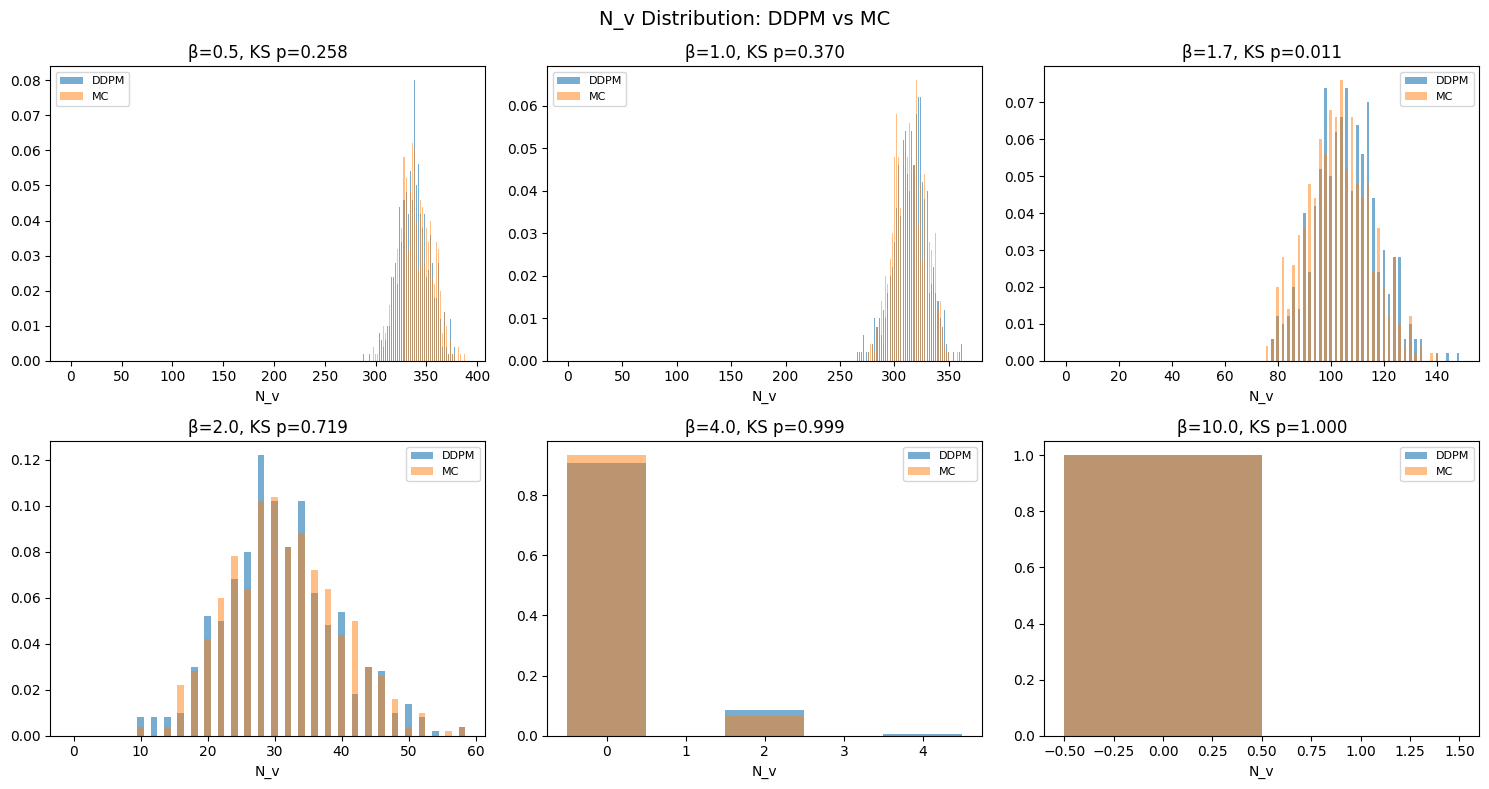

In [22]:
# ═══ 8. 本題: N_v 分布比較 ═══
mc_betas = sorted([b for b in all_betas if topo[b]['mc'] is not None])

print('N_v 分布比較 (KS検定)')
print(f"{'β':>5} {'⟨Nv⟩_MC':>9} {'⟨Nv⟩_DDPM':>10} {'KS stat':>8} {'KS p':>8} {'W₁':>6}")
print('─'*55)
for beta in mc_betas:
    me = topo[beta]['mc']; ge = topo[beta]['gen']
    ks, p = ks_2samp(me['Nv'], ge['Nv'])
    w1 = wasserstein_distance(me['Nv'].astype(float), ge['Nv'].astype(float))
    print(f"{beta:5.2f} {me['Nv_mean']:9.1f} {ge['Nv_mean']:10.1f} {ks:8.4f} {p:8.4f} {w1:6.2f}")

# ヒストグラム
pbetas = [b for b in [0.5,1.0,1.7,2.0,4.0,10.0] if b in mc_betas]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
for i, beta in enumerate(pbetas):
    ax = axes[i]; me = topo[beta]['mc']; ge = topo[beta]['gen']
    mx = max(np.max(me['Nv']), np.max(ge['Nv']), 1)
    bins = np.arange(-0.5, mx+1.5, 1)
    ax.hist(ge['Nv'], bins=bins, density=True, alpha=0.6, color='C0', label='DDPM')
    ax.hist(me['Nv'], bins=bins, density=True, alpha=0.5, color='C1', label='MC')
    _, p = ks_2samp(me['Nv'], ge['Nv'])
    ax.set_title(f'β={beta:.1f}, KS p={p:.3f}'); ax.set_xlabel('N_v'); ax.legend(fontsize=8)
for j in range(len(pbetas), len(axes)): axes[j].set_visible(False)
fig.suptitle('N_v Distribution: DDPM vs MC', fontsize=14)
plt.tight_layout(); plt.savefig(OUTDIR/'Nv_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

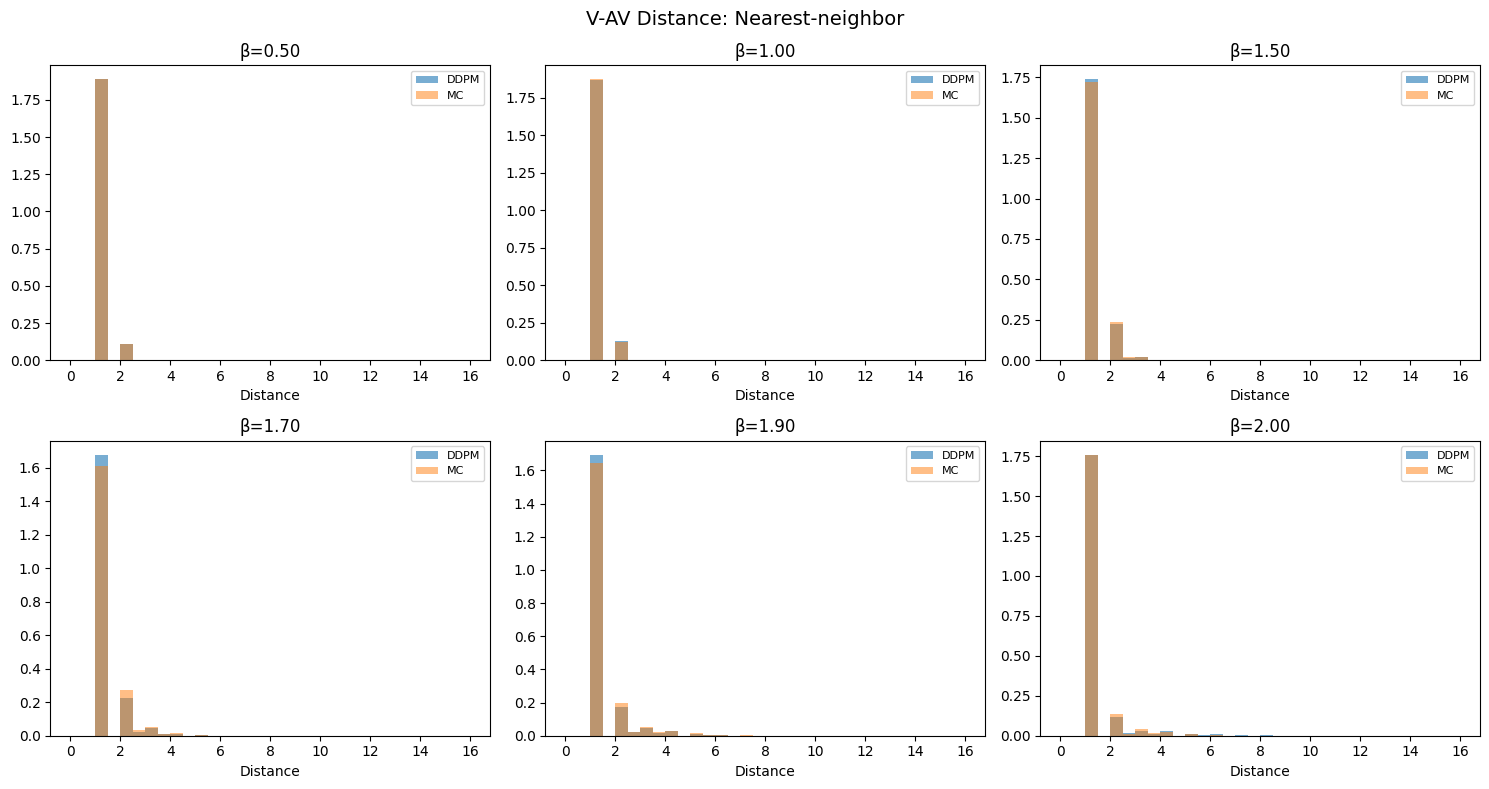

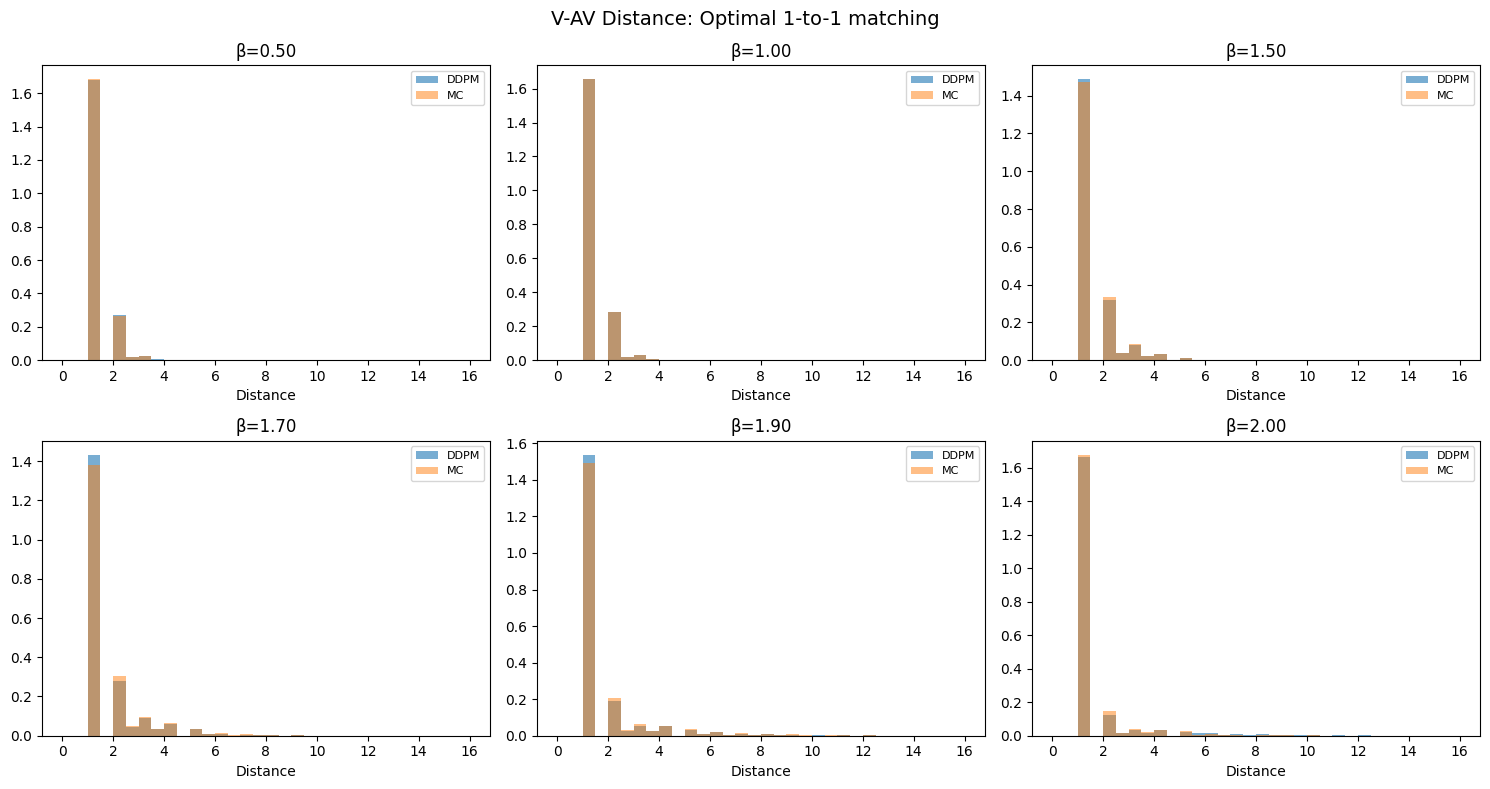

In [23]:
# ═══ 9. V-AV 最近接距離 + 1対1マッチング ═══
dist_betas = [b for b in [0.5,1.0,1.5,1.7,1.9,2.0] if b in all_betas]

for fn, tag, fname in [(nn_vav_dist,'Nearest-neighbor','surrogate'),
                        (matched_vav_dist,'Optimal 1-to-1 matching','matching')]:
    fig, axes = plt.subplots(2,3,figsize=(15,8)); axes = axes.flatten()
    for i, beta in enumerate(dist_betas):
        ax = axes[i]
        gd = [d for a in topo[beta]['gen']['analyses'][:200] for d in fn(a['vortex_map'])]
        if gd: ax.hist(gd, bins=np.linspace(0,16,33), density=True, alpha=0.6, color='C0', label='DDPM')
        me = topo[beta].get('mc')
        if me:
            md = [d for a in me['analyses'][:200] for d in fn(a['vortex_map'])]
            if md: ax.hist(md, bins=np.linspace(0,16,33), density=True, alpha=0.5, color='C1', label='MC')
        ax.set_title(f'β={beta:.2f}'); ax.set_xlabel('Distance'); ax.legend(fontsize=8)
    for j in range(len(dist_betas), len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'V-AV Distance: {tag}', fontsize=14)
    plt.tight_layout(); plt.savefig(OUTDIR/f'vav_{fname}.png', dpi=150, bbox_inches='tight'); plt.show()

In [30]:
# ═══ 10. 最終サマリー ═══
print('='*70)
print('最終サマリー: Phase 2b トポロジカル監査')
print('='*70)

print('\n[A] Q=0 検証:')
mc_q = [topo[b]['mc']['Q_nonzero_frac'] for b in all_betas if topo[b]['mc']]
gen_q = [topo[b]['gen']['Q_nonzero_frac'] for b in all_betas]
print(f'  MC  Q≠0 率: max {max(mc_q)*100:.1f}%' if mc_q else '  MC データなし')
print(f'  DDPM Q≠0 率: max {max(gen_q)*100:.1f}%')

print('\n[B] N_v 分布 (KS検定):')
for beta in mc_betas:
    me = topo[beta]['mc']; ge = topo[beta]['gen']
    _, p = ks_2samp(me['Nv'], ge['Nv'])
    print(f"  β={beta:5.2f}: p={p:.4f}", '✓' if p>0.05 else '△' if p>0.01 else '✗')

print('\n[C] Projection sensitivity:')
for beta in sorted(all_betas):
    d = topo[beta]['gen']['Nv_mean'] - topo[beta]['gen_raw']['Nv_mean']
    print(f"  β={beta:5.2f}: Δ⟨Nv⟩={d:+.2f}")

print('\n[D] 住山・中村論文との接続:')
print('  本実験: U(1), T²×S¹, π₁ vortex 欠陥の統計')
print('  住山:   SU(2), R³×S¹, π₃ winding (Ct)')
print('  共通: Polyakov loop のトポロジーが閉じ込めの情報を持つ')

print('\n出力ファイル:')
for f in sorted(Path('/kaggle/working').glob('*.npz')) + sorted(Path('/kaggle/working').glob('*.png')):
    print(f'  {f.name} ({f.stat().st_size/1024:.0f} KB)')
print('\n完了 ✓')

最終サマリー: Phase 2b トポロジカル監査

[A] Q=0 検証:
  MC  Q≠0 率: max 0.0%
  DDPM Q≠0 率: max 0.0%

[B] N_v 分布 (KS検定):
  β= 0.50: p=0.2576 ✓
  β= 1.00: p=0.3699 ✓
  β= 1.50: p=0.0001 ✗
  β= 1.70: p=0.0110 △
  β= 1.90: p=0.6126 ✓
  β= 2.00: p=0.7189 ✓
  β= 2.50: p=0.7704 ✓
  β= 4.00: p=0.9988 ✓
  β= 6.00: p=1.0000 ✓
  β=10.00: p=1.0000 ✓

[C] Projection sensitivity:
  β= 0.50: Δ⟨Nv⟩=+0.00
  β= 1.00: Δ⟨Nv⟩=+0.00
  β= 1.50: Δ⟨Nv⟩=+0.00
  β= 1.70: Δ⟨Nv⟩=+0.00
  β= 1.75: Δ⟨Nv⟩=+0.00
  β= 1.85: Δ⟨Nv⟩=+0.00
  β= 1.90: Δ⟨Nv⟩=+0.00
  β= 2.00: Δ⟨Nv⟩=+0.00
  β= 2.50: Δ⟨Nv⟩=+0.00
  β= 3.00: Δ⟨Nv⟩=+0.00
  β= 4.00: Δ⟨Nv⟩=+0.00
  β= 6.00: Δ⟨Nv⟩=+0.00
  β= 8.00: Δ⟨Nv⟩=+0.00
  β=10.00: Δ⟨Nv⟩=+0.00

[D] 住山・中村論文との接続:
  本実験: U(1), T²×S¹, π₁ vortex 欠陥の統計
  住山:   SU(2), R³×S¹, π₃ winding (Ct)
  共通: Polyakov loop のトポロジーが閉じ込めの情報を持つ

出力ファイル:
  phase2b_data.npz (138094 KB)
  Nv_distribution.png (105 KB)
  audit_rounding.png (41 KB)
  vav_matching.png (87 KB)
  vav_surrogate.png (85 KB)

完了 ✓
